Actividad Fundamental 7. Redes Neuronales Artificiales.

Luis Alfonso García Escobedo 2105438 N4

Emilio Betancourt Gonzalez 2100254 N4

Cristian Javier Rodríguez Aguirre 2095105 V6

Aranza Carballo Lemus 2178073 N4

Angel Gabriel Ibarra Lomeli 2010528 N4

1. Cargar librerías.

In [37]:
# TensorFlow y tf.keras
import tensorflow as tf
from tensorflow import keras

# Librerías
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.20.0


2. Cargar datos.

In [38]:
mnist = keras.datasets.mnist

(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

In [39]:
# Explorando el set de datos.
train_data.shape

(60000, 28, 28)

In [40]:
len(train_labels)

60000

In [41]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [42]:
test_data.shape

(10000, 28, 28)

In [43]:
len(test_labels)

10000

3. Preprocesamiento de datos.

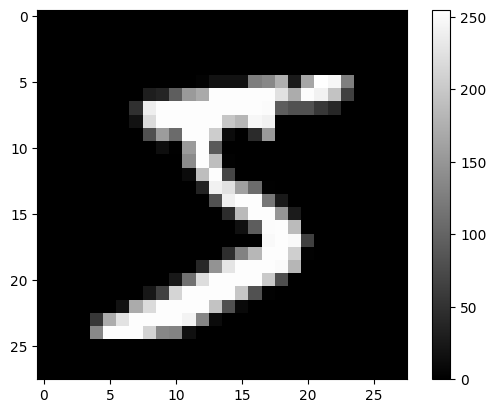

In [44]:
plt.figure()
plt.imshow(train_data[0], cmap='gray')
plt.colorbar()
plt.grid(False)
plt.show()

In [45]:
train_data = train_data / 255.0
test_data = test_data / 255.0

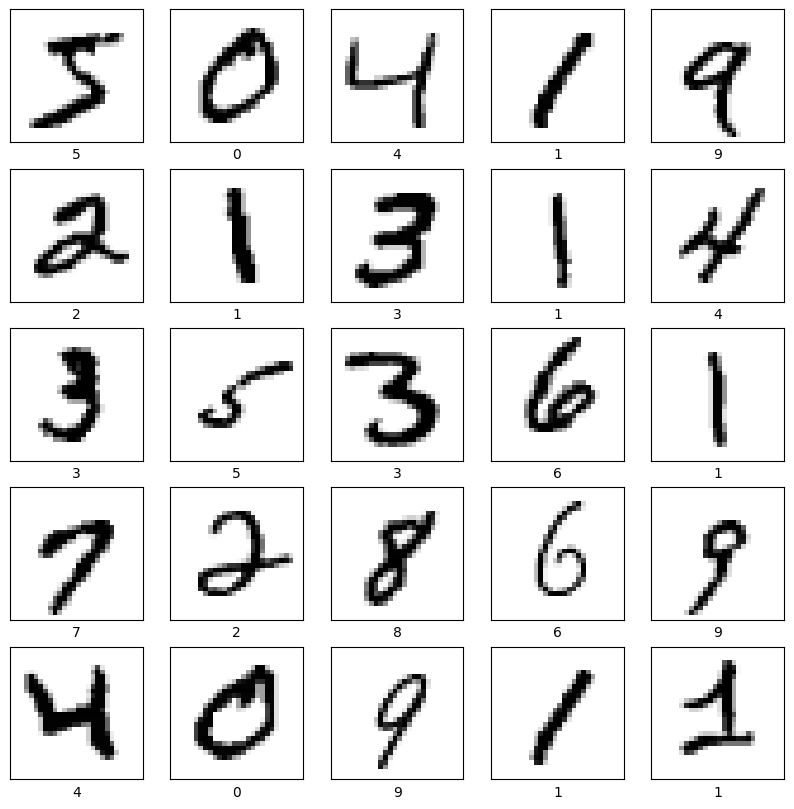

In [46]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_data[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])

plt.show()

4. Selección y entrenamiento del modelo.

In [47]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [48]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [49]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [50]:
model.fit(train_data, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9261 - loss: 0.2603
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9655 - loss: 0.1167
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9757 - loss: 0.0808
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9818 - loss: 0.0595
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0475
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9880 - loss: 0.0379
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9910 - loss: 0.0297
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9926 - loss: 0.0247
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9937 - loss: 0.0200
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9954 - loss: 0.0161


In [51]:
test_loss, test_acc = model.evaluate(test_data, test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9782 - loss: 0.0816

Test accuracy: 0.9782000184059143


5. Prueba del modelo.

In [52]:
predictions = model.predict(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [53]:
predictions[0]

array([9.7477777e-13, 3.9568361e-14, 1.6135797e-10, 9.9587155e-08,
       7.9055173e-17, 7.5822725e-13, 3.0725599e-18, 9.9999982e-01,
       2.0324537e-11, 1.8973617e-08], dtype=float32)

In [54]:
np.argmax(predictions[0])

np.int64(7)

In [55]:
test_labels[0]

np.uint8(7)

In [56]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]

  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)

  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]

  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])

  thisplot = plt.bar(range(10), predictions_array, color="#777777")

  plt.ylim([0, 1])

  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

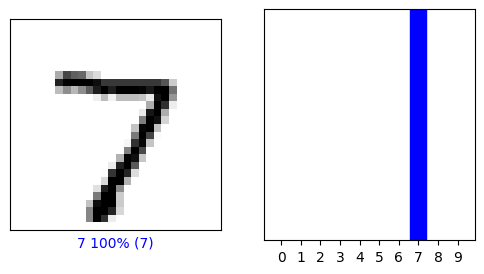

In [57]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_data)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

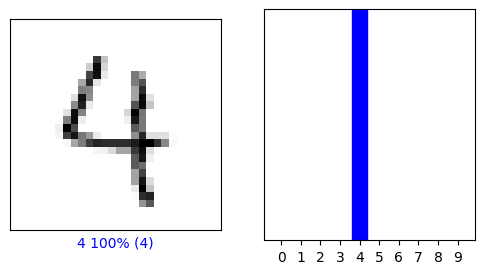

In [58]:
i = 24
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_data)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

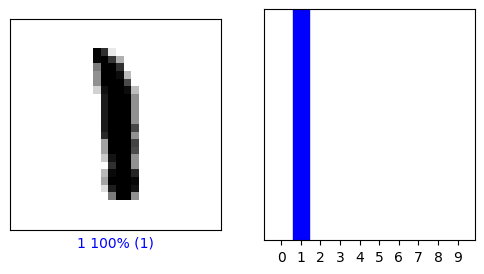

In [59]:
i = 777
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_data)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

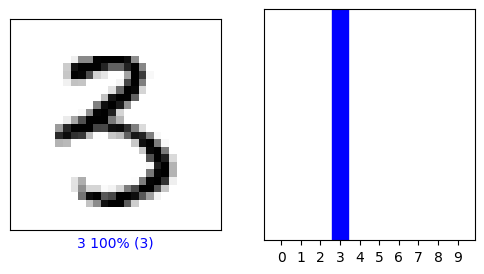

In [60]:
i = 5000
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_data)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

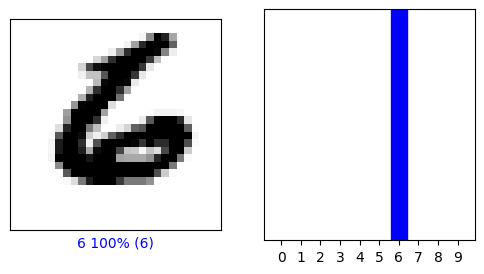

In [61]:
i = 9999
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_data)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()